# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [46]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [47]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [48]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [49]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [50]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [51]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [52]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [53]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [54]:

# cantidad de nulos para users
users.isnull().agg(['sum','mean'])



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
sum,0.0,0.0,0.0,0.0,469.00000,0.0,0.0,3534.0000
mean,0.0,0.0,0.0,0.0,0.11725,0.0,0.0,0.8835


In [55]:
# cantidad de nulos para usage

usage.isnull().agg(['sum','mean'])

,id,user_id,type,date,duration,length
sum,0.0,0.0,0.0,50.00000,22076.0000,17896.0000
mean,0.0,0.0,0.0,0.00125,0.5519,0.4474


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

##PLANS 
- Este dataset no requiere limpieza ya que los nulos son inexistentes.

##USERS
- La columna "CITY" contiene un valor de nulos moderada con un porcentaje faltante de 11.7%
- Lo ideal seria imputar y analizar si afecta a la segmentacion geografica

##USAGE
- En este dataset nos encontramos con 3 columnas que contienen valores nulos: 'date', 'duration' y 'length'.
- En el caso de 'date' representa un porcentajo bastante bajo con apenas el 0.1%. Con esto en mente se podria proceder a eliminar las filas con valores nulos ya que el impacto seria minimo.
- Por el caso contrario de lo que pasa con 'date', tenemos la columna 'duration' con un porcentaje de nulos del 55%. Aunque el numero representa mas de la mitad de los datos no es necesario imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [56]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... No requiere limpieza ya que nos muestra valores dentro del rango normal/esperado.
- La columna `age` ... en este caso nos muestra un valor sentinil de '-999' como valor minimo. Lo recomendable seria reemplazarlo por NaN y luego imputar o eliminar esos registros.

In [57]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son columnas identificadoras. Por ejemplo 'id' es unico por registro mientras que 'user_id' nos permite saber que usuario realizo el movimiento.
- La columna 'duration' prodria revisarse con mas detencion ya que nos muestra valores minimos de 0 y maximos de 120. Aunque podria ser algo totalmente normal debido al negocio, no estraia de mas validar la informacion. Lo mismo sucede con la columna 'length', contiene valores maximos de 1490, por lo que vale la pena revisarse.

In [58]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    display(users[col].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64

- Dentro de la columna `city`, existe una fila con representacion '?'. Podriamos reemplazar por NaN para despues imputar.
- La columna `plan`, solo muestra dos columnas en las cuales no se detectan valores nulos.

In [59]:

# explorar columna categórica de usage
usage['type'].value_counts() # completa el código


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` solo tiene dos datos 'text' y 'call' los cuales no representan datos faltantes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

- Se encontro en la columna 'age' un sentinel representado por -999. Mientras que en city un valor faltante representado por '?'.

En el caso de 'age', al ser un sentinel los mas viable seria realizar un replace with NaN para despues proceder a imputar.

And with 'city' se podria realizar el mismo procedimiento.
 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [60]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce') # completa el código

In [61]:
users['reg_date'].head()

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]

In [62]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce') # completa el código

In [63]:
usage['date'].head()

0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]

In [64]:
# Revisar los años presentes en `reg_date` de users

users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves

Al estar trabajando con una base de datos en la cual el tope/limite de registro es el año 2024, nos percatamos de que existen 40 registros documentados bajo el año 2026. Lo cual es claramente incorrecto, lo ideal seria realizar la correccion de los mismos para evitar posibles alteraciones a la informacion y posibles errores en anaisis futuros.

In [65]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves. 

En seccion no se notan fechas fuera de rango. Por lo cual es seguro mecionar de que las fechas son consistentes.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Como se menciona en el apartado anterior, in column 'reg_date' se identifican valores correspondientes al año 2026, lo cual es eroneo ya que la base de datos tiene como limite el año 2026. Se recomienda corregir o eliminar estos registros. Mientras que en la columna 'date', los datos encontrados corresponden al año 2024, por lo cual es seguro decir que la informacion es correcta.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [66]:
# Reemplazar -999 por la mediana de age
median_age = users.loc[users['age']!= -999,'age'].median()
users['age'] = users['age'].replace(-999,median_age)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [67]:
users['age'].head()

0    38.0
1    53.0
2    57.0
3    69.0
4    63.0
Name: age, dtype: float64

In [68]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [69]:
users['city'].head()

0    Medellín
1        <NA>
2        CDMX
3      Bogotá
4         GDL
Name: city, dtype: object

In [70]:
# Marcar fechas futuras como NA para reg_date

users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024)

# Verificar cambios

users[users['reg_date'].dt.year > 2024]


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


In [71]:
users[users['reg_date'].isna()]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59.0,Medellín,NaT,Basico,NaN
56,10056,Luis,Garcia,29.0,CDMX,NaT,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45.0,CDMX,NaT,Basico,NaN
70,10070,Mariana,Gomez,50.0,CDMX,NaT,Premium,NaN
248,10248,Sofia,Garcia,20.0,Medellín,NaT,Premium,"1,72506E+18"
320,10320,Sofia,Garcia,74.0,GDL,NaT,Premium,NaN
326,10326,Mariana,Torres,51.0,Medellín,NaT,Premium,NaN
505,10505,Luis,Garcia,75.0,CDMX,NaT,Basico,NaN
527,10527,Carlos,Torres,71.0,MTY,NaT,Basico,NaN
646,10646,Luis,Ramirez,50.0,CDMX,NaT,Premium,NaN


In [72]:
users[['age', 'city', 'reg_date']].head(10)

,age,city,reg_date
0,38.0,Medellín,2022-01-01 00:00:00.000000000
1,53.0,<NA>,2022-01-01 06:34:17.914478619
2,57.0,CDMX,2022-01-01 13:08:35.828957239
3,69.0,Bogotá,2022-01-01 19:42:53.743435858
4,63.0,GDL,2022-01-02 02:17:11.657914478
5,61.0,MTY,2022-01-02 08:51:29.572393098
6,39.0,Bogotá,2022-01-02 15:25:47.486871717
7,70.0,Medellín,2022-01-02 22:00:05.401350337
8,76.0,CDMX,2022-01-03 04:34:23.315828957
9,47.0,Bogotá,2022-01-03 11:08:41.230307576


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [73]:
# Verificación MAR en usage (Missing At Random) para duration

(usage
    .groupby('type')[['duration','length']]
    .apply(lambda x: x.isnull().mean()))

,duration,length
type,,
call,0.000000,0.99933
text,0.999276,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Al correr este codigo, nos percatamos de que efectivamente existen valores nulos. Podemos visualizar que bajo 'call' existen valores nulos solamente en 'duration'. Algo similar sucede con 'text', unicamente existen valores nulos bajo 'lenght'. Con esto se determina de que si, en efecto, los valores nulos no son aleatorios y dependen de la columna 'type'. Al removerlos el anilisis se veria afectado, por ello he decidido mantenerlos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [74]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
    .groupby('user_id')
    .agg({
        'is_text':'sum',
        'is_call':'sum',
        'duration':'sum'})
    .reset_index()) 

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [75]:
# Renombrar columnas

usage_agg=usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call':'cant_llamadas',
    'duration':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [76]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on='user_id',how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [77]:
usage_agg = (
    usage
    .assign(
        is_text=lambda x: (x['type'] == 'text').astype(int),
        is_call=lambda x: (x['type'] == 'call').astype(int)
    )
    .groupby('user_id')
    .agg(
        cant_mensajes=('is_text', 'sum'),
        cant_llamadas=('is_call', 'sum'),
        cant_minutos_llamada=('duration', 'sum')
    )
    .reset_index()
)

user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [78]:
# Resumen estadístico de las columnas numéricas

user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [79]:
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].agg(['mean', 'median', 'min', 'max'])

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
mean,48.136,5.524381,4.47812,23.317054
median,48.000,5.000000,4.00000,19.780000
min,18.000,0.000000,0.00000,0.000000
max,79.000,17.000000,15.00000,155.690000


In [80]:
# Distribución porcentual del tipo de plan

users['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

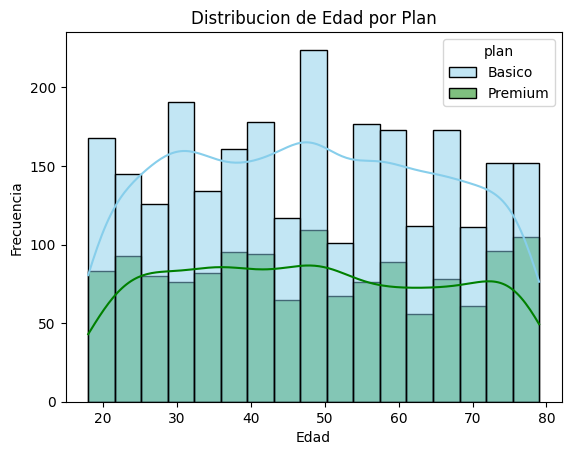

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age', hue='plan', palette=['skyblue','green'],kde=True)
plt.title('Distribucion de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

En esta grafica es muy notable de que laa distribucion es bastante uniforme entre los 20 y 80 año. De igual manera observamos que el plan 'Basico' supera al 'Premium' en todos los rangos de edad, en especial con las edades que oscilan los 48–50 años. Mientras que el plan 'Premium' mantiene una presencia estable, esto nos da como conclusion de que la edad no es un factor diferenciador fuerte para la adopcion del plan Premium.

In [38]:
df_usage = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

In [39]:
df = df_usage.merge(users[['user_id','plan']], on='user_id', how='left')

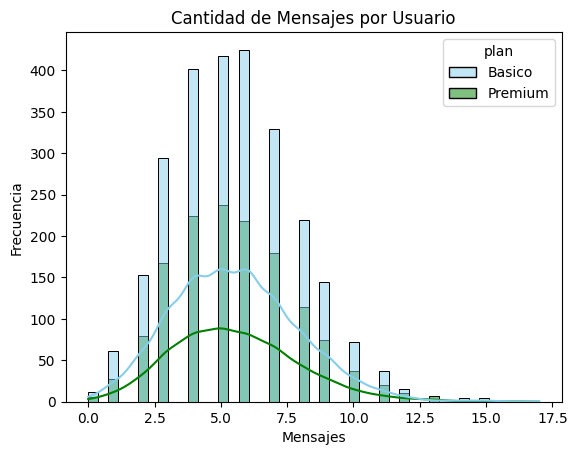

In [40]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=df, x='is_text', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Cantidad de Mensajes por Usuario')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

On the contrary que con la grafica de 'Edad' aqui obsevamos un sesgo hacia a la derecha. La mayoria de usuarios envían entre 3 y 7 mensajes. Los clientes con el plan 'Basico' dominan en frecuencia total, con un maximo entre 5–6 mensajes. Los clientes que cuentan con el plan 'Premium' tienden a ser mas moderados entre 4–6 mensajes. Pocos usuarios de ambos planes superan los 10 mensajes, lo que indica un uso moderado general.'.

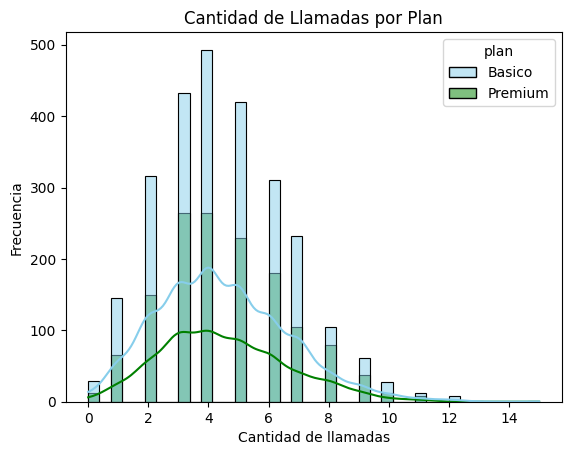

In [41]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=df, x='is_call', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


Al igual que en la grafica de 'Textos' aqui obsevamos un sesgo hacia a la derecha, con la mayoria de usuarios concentrados entre 3 y 6 llamadas. El punto mas alto del plan 'Basico' esta en 4 llamadas, mientras que el 'Premium' oscila entre 3 y 5. De igual manera notamos que los usuarios con el plan 'Premium' tienden a hacer mas llamadas que los del plan 'Basico'....

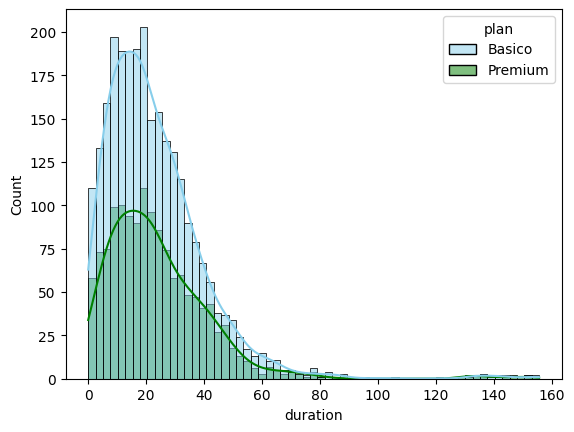

In [42]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=df,x='duration',hue='plan',palette=['skyblue','Green'],kde=True)
plt.title=('Minutos Totales de Llamada por Paln')
plt.xlabel=('Minutos de Llamada')
plt.ylabel=('Frecuencia')
plt.show()


💡Insights: 

De todas las graficas esta es la que mas sesgo arroja. Fuertemente concentrada cerca de 0 y con cola muy larga hacia la derecha. La gran mayoria de sesiones duran menos de 5 unidades de tiempo, tanto en los planes 'Basico' como en 'Premium'. El comportamiento es casi identico entre ambos planes. La presencia de valores extremos sugiere datos atipicos o posibles outliers que vale la pena investigar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [43]:
print(user_profile.columns.tolist())

['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


TypeError: 'str' object is not callable

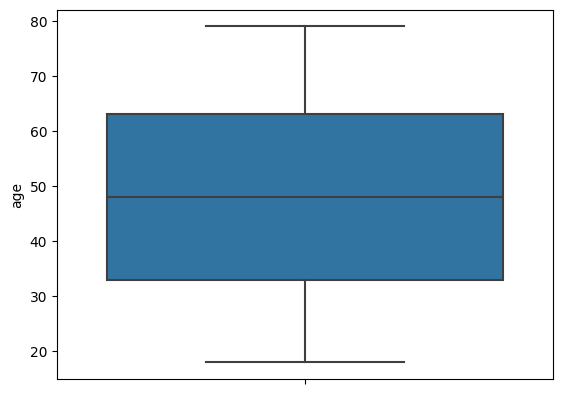

In [88]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    fig,ax=plt.subplots()
    sns.boxplot(y=user_profile[col],ax=ax)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [86]:
# Calcular límites con el método IQR



columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"{col}:")
    print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}\n")
    



cant_mensajes:
Q1 = 4.0, Q3 = 7.0, IQR = 3.0

cant_llamadas:
Q1 = 3.0, Q3 = 6.0, IQR = 3.0

cant_minutos_llamada:
Q1 = 11.12, Q3 = 31.415, IQR = 20.295



In [87]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Lo mantenemos, el valor no es necesariamente alto comparado con el Q3. Los outliers corresponden a usuarios con mayor actividad y no necesariamente a anomalias en los datos.
- cant_llamadas: mantener o no outliers, porqué?Al igual que con mensajes, el maximo sigue representando un valor razonable. Los outliers aqui tambien representan a usuarios con mayor actividad y no necesariamente a anomalias en los datos.
- cant_minutos_llamada: mantener o no outliers, porqué? EN este caso es un poco mas complicado. Por el momento, lo mantenemos. Esto debido a que los outliers son debido a un segmento de usuarios con alto consumo. Al eliminarlos se omite informacion de alto valor.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [90]:
# Crear columna grupo_uso

def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [91]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [92]:
# Crear columna grupo_edad

def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [93]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

TypeError: 'str' object is not callable

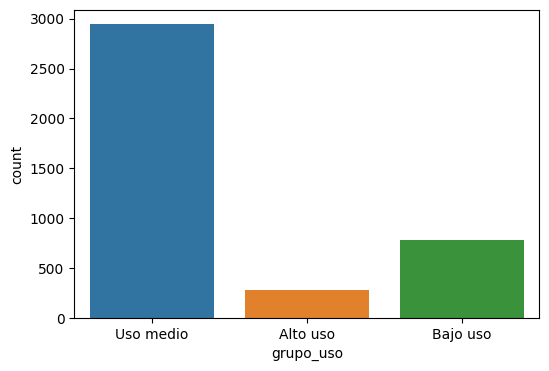

In [94]:
# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')

plt.show()

TypeError: 'str' object is not callable

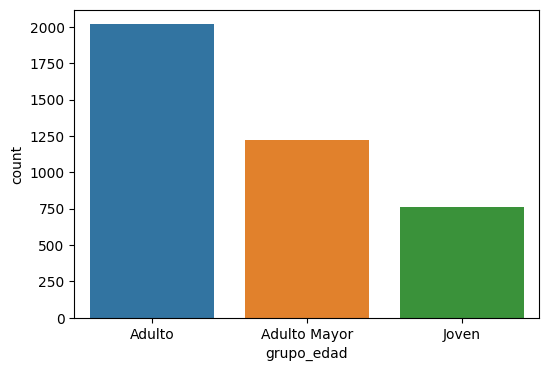

In [95]:
# Visualización de los segmentos por edad

plt.figure(figsize=(6,4))

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

Analisis ejecutivo – ConnectaTel
1. Problemas iniciales de los datos
El dataset de ConnectaTel no presento problemas criticos de calidad como valores nulos o inconsistencias estructurales. Sin embargo, si se identifico una alta disparidad en el comportamiento de los usuarios, especialmente en las variables de consumo (mensajes, llamadas y minutos).
Se detectaron valores atipicos en las tres variables mediante el metodo IQR, especialmente en minutos de llamada, donde el valor maximo (155.69) se aleja significativamente del rango intercuartilico. Estos outliers no corresponden a errores de datos, sino a usuarios con niveles de consumo muy superiores al promedio.
2. Segmentacion de clientes y comportamiento
Se construyeron dos segmentaciones principales: una basada en el nivel de uso y otra en la edad.
En la segmentacion por uso se identificaron tres grupos: bajo uso, uso medio y alto uso. La mayoria de los usuarios se concentra en los niveles bajo y medio, mientras que el grupo de alto uso representa una minoria con consumo intensivo.
En la segmentacion por edad se definieron tres grupos: jovenes, adultos y adultos mayores. Los jovenes tienden a un mayor uso de mensajeria, los adultos presentan un comportamiento mas equilibrado entre llamadas y mensajes, y los adultos mayores muestran un menor nivel de uso general, con mayor peso en llamadas.
3. Segmentos mas valiosos
Los segmentos mas valiosos para la empresa son los usuarios de alto uso, ya que concentran el mayor consumo de servicios y, por lo tanto, el mayor potencial de ingresos. Tambien destacan los usuarios adultos con consumo medio, debido a su estabilidad y comportamiento consistente, lo que los convierte en un segmento clave para la base recurrente de ingresos.
4. Outliers y su implicacion
Los valores atipicos detectados en las variables de consumo representan usuarios con comportamiento intensivo, especialmente en duracion de llamadas. Estos usuarios no deben considerarse errores, sino un segmento relevante del negocio conocido como heavy users.
Su presencia indica una distribucion sesgada del consumo, donde pocos usuarios concentran un nivel de uso significativamente mayor. Eliminarlos distorsionaria las metricas agregadas y ocultaria informacion importante para el analisis del negocio.
5. Recomendaciones
Se recomienda estructurar la oferta de la empresa en funcion del nivel real de consumo de los usuarios, diferenciando planes basicos, intermedios y premium. Los planes deben alinearse con los patrones de uso observados para evitar subsidios cruzados entre usuarios de bajo y alto consumo.
Asimismo, se sugiere utilizar el nivel de uso como variable principal de segmentacion, por encima de la edad, ya que el comportamiento de consumo es el principal factor diferenciador.
Los usuarios de alto consumo deben ser monitoreados como un segmento estrategico debido a su impacto en ingresos, mientras que los usuarios de consumo medio representan el nucleo estable del negocio y deben ser prioritarios en estrategias de retencion.


Conclusion
El analisis de ConnectaTel evidencia que la principal fuente de valor no esta en una distribucion homogenea de usuarios, sino en segmentos claramente diferenciados por nivel de consumo. Los usuarios de alto uso concentran gran parte del valor economico, mientras que los usuarios medios aportan estabilidad al negocio. Los outliers no representan errores, sino un segmento estrategico clave que debe ser incorporado en la definicion de productos y estrategias comerciales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`